# Day 5 — Prediction Targets, Lagged Features and Baselines

## Goal
Build a properly aligned prediction dataset and establish
simple benchmarks for predicting AAPL's next-day direction.

## Topics
- Features and targets
- Lagged features
- Future returns
- Chronological train/test split
- Feature-target correlation
- Majority-class baseline
- Previous-day direction baseline
- Accuracy and balanced accuracy
- Look-ahead bias and data leakage

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/raw/AAPL_daily_raw.csv",
    index_col="Date",
    parse_dates=True
)

data = data.sort_index()

data.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,daily_return
Date,,,,,,,,,
2015-01-02 00:00:00-05:00,27.847500,27.860001,26.837500,27.332500,24.171755,212818400,0.0,0.0,NaN
2015-01-05 00:00:00-05:00,27.072500,27.162500,26.352501,26.562500,23.490799,257142000,0.0,0.0,-0.028172
2015-01-06 00:00:00-05:00,26.635000,26.857500,26.157499,26.565001,23.493013,263188400,0.0,0.0,0.000094
2015-01-07 00:00:00-05:00,26.799999,27.049999,26.674999,26.937500,23.822430,160423600,0.0,0.0,0.014022
2015-01-08 00:00:00-05:00,27.307501,28.037500,27.174999,27.972500,24.737757,237458000,0.0,0.0,0.038423


In [4]:
data.columns.tolist()

['Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Dividends',
 'Stock Splits',
 'daily_return']

In [5]:
data["daily_return"] = data["Adj Close"].pct_change()

data["SMA_20"] = data["Adj Close"].rolling(20).mean()
data["SMA_50"] = data["Adj Close"].rolling(50).mean()
data["SMA_200"] = data["Adj Close"].rolling(200).mean()

data["EMA_12"] = (
    data["Adj Close"].ewm(span=12, adjust=False).mean()
)

data["EMA_26"] = (
    data["Adj Close"].ewm(span=26, adjust=False).mean()
)

data["price_to_SMA20"] = (
    data["Adj Close"] / data["SMA_20"] - 1
)

data["SMA20_to_SMA50"] = (
    data["SMA_20"] / data["SMA_50"] - 1
)

data["momentum_10d"] = (
    data["Adj Close"] / data["Adj Close"].shift(10) - 1
)

data["rolling_20d_volatility"] = (
    data["daily_return"].rolling(20).std()
)

In [6]:
delta = data["Adj Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

rs = avg_gain / avg_loss

data["RSI_14"] = 100 - (100 / (1 + rs))

In [7]:
data["MACD"] = data["EMA_12"] - data["EMA_26"]

data["MACD_signal"] = (
    data["MACD"].ewm(span=9, adjust=False).mean()
)

data["MACD_hist"] = data["MACD"] - data["MACD_signal"]

In [8]:
rolling_std_20 = data["Adj Close"].rolling(20).std()

data["BB_upper"] = data["SMA_20"] + 2 * rolling_std_20
data["BB_lower"] = data["SMA_20"] - 2 * rolling_std_20

data["BB_percent_b"] = (
    (data["Adj Close"] - data["BB_lower"])
    / (data["BB_upper"] - data["BB_lower"])
)

data["volume_change"] = data["Volume"].pct_change()

data["volume_SMA20"] = data["Volume"].rolling(20).mean()

data["relative_volume"] = (
    data["Volume"] / data["volume_SMA20"]
)

In [9]:
data["return_lag_1"] = data["daily_return"].shift(1)

data["return_lag_5"] = data["daily_return"].shift(5)

In [10]:
data[["daily_return", "return_lag_1", "return_lag_5"]].tail(10)

,daily_return,return_lag_1,return_lag_5
Date,,,
2025-12-17 00:00:00-05:00,-0.010087,0.001824,0.005772
2025-12-18 00:00:00-05:00,0.001287,-0.010087,-0.002690
2025-12-19 00:00:00-05:00,0.005438,0.001287,0.000899
2025-12-22 00:00:00-05:00,-0.009866,0.005438,-0.014985
2025-12-23 00:00:00-05:00,0.005130,-0.009866,0.001824
2025-12-24 00:00:00-05:00,0.005324,0.005130,-0.010087
2025-12-26 00:00:00-05:00,-0.001497,0.005324,0.001287
2025-12-29 00:00:00-05:00,0.001317,-0.001497,0.005438
2025-12-30 00:00:00-05:00,-0.002484,0.001317,-0.009866


In [11]:
#Creating Next Day Adjusted Close Price Column
data["next_adj_close"] = data["Adj Close"].shift(-1)

In [12]:
#Creating Future Return Column
data["future_return_1d"] = (data["next_adj_close"] / data["Adj Close"] - 1)

data[["Adj Close", "next_adj_close", "future_return_1d"]].tail(10)

,Adj Close,next_adj_close,future_return_1d
Date,,,
2025-12-17 00:00:00-05:00,271.102081,271.451111,0.001287
2025-12-18 00:00:00-05:00,271.451111,272.927155,0.005438
2025-12-19 00:00:00-05:00,272.927155,270.234436,-0.009866
2025-12-22 00:00:00-05:00,270.234436,271.620667,0.005130
2025-12-23 00:00:00-05:00,271.620667,273.066711,0.005324
2025-12-24 00:00:00-05:00,273.066711,272.657837,-0.001497
2025-12-26 00:00:00-05:00,272.657837,273.016876,0.001317
2025-12-29 00:00:00-05:00,273.016876,272.338684,-0.002484
2025-12-30 00:00:00-05:00,272.338684,271.122009,-0.004468


In [13]:
#Creating Binary Target Column for Next Day Price Movement
data["target_up"] = (data["future_return_1d"] > 0).astype(float)

data.loc[data["future_return_1d"].isna(),"target_up"] = np.nan

In [14]:
#Inspecting the last 10 rows of the target_up column 
data[["Adj Close", "future_return_1d", "target_up"]].tail(10)

,Adj Close,future_return_1d,target_up
Date,,,
2025-12-17 00:00:00-05:00,271.102081,0.001287,1.0
2025-12-18 00:00:00-05:00,271.451111,0.005438,1.0
2025-12-19 00:00:00-05:00,272.927155,-0.009866,0.0
2025-12-22 00:00:00-05:00,270.234436,0.005130,1.0
2025-12-23 00:00:00-05:00,271.620667,0.005324,1.0
2025-12-24 00:00:00-05:00,273.066711,-0.001497,0.0
2025-12-26 00:00:00-05:00,272.657837,0.001317,1.0
2025-12-29 00:00:00-05:00,273.016876,-0.002484,0.0
2025-12-30 00:00:00-05:00,272.338684,-0.004468,0.0


In [15]:
#Defining the feature columns for the machine learning model
feature_columns = [
    "daily_return",
    "return_lag_1",
    "return_lag_5",
    "rolling_20d_volatility",
    "SMA_20",
    "SMA_50",
    "SMA_200",
    "EMA_12",
    "EMA_26",
    "price_to_SMA20",
    "SMA20_to_SMA50",
    "momentum_10d",
    "RSI_14",
    "MACD",
    "MACD_signal",
    "MACD_hist",
    "BB_percent_b",
    "volume_change",
    "relative_volume"
]

In [16]:
#Peparing the label dataset
model_data = data[feature_columns + ["future_return_1d", "target_up"]].dropna().copy()
model_data = model_data.sort_index()
model_data.shape

(2566, 21)

In [17]:
#Checking the null values result 
model_data[feature_columns].isna().sum()

daily_return              0
return_lag_1              0
return_lag_5              0
rolling_20d_volatility    0
SMA_20                    0
SMA_50                    0
SMA_200                   0
EMA_12                    0
EMA_26                    0
price_to_SMA20            0
SMA20_to_SMA50            0
momentum_10d              0
RSI_14                    0
MACD                      0
MACD_signal               0
MACD_hist                 0
BB_percent_b              0
volume_change             0
relative_volume           0
dtype: int64

In [18]:
model_data[["future_return_1d", "target_up"]].head()

,future_return_1d,target_up
Date,,
2015-10-16 00:00:00-04:00,0.006214,1.0
2015-10-19 00:00:00-04:00,0.018258,1.0
2015-10-20 00:00:00-04:00,-0.000088,0.0
2015-10-21 00:00:00-04:00,0.015295,1.0
2015-10-22 00:00:00-04:00,0.030996,1.0


In [19]:
#Splitting the dataset into training and testing sets chronologically
split_index = int(len(model_data) * 0.80)

train = model_data.iloc[:split_index].copy()
test = model_data.iloc[split_index:].copy()

print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period: ", test.index.min(), "to", test.index.max())

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training period: 2015-10-16 00:00:00-04:00 to 2023-12-11 00:00:00-05:00
Testing period:  2023-12-12 00:00:00-05:00 to 2025-12-30 00:00:00-05:00
Training rows: 2052
Testing rows: 514


In [20]:
#Calculating the correlation between each feature and the target variable
feature_target_corr = train[feature_columns].corrwith(train["future_return_1d"])

corr_summary = pd.DataFrame({"correlation": feature_target_corr,
"absolute_correlation": feature_target_corr.abs()}).sort_values("absolute_correlation", ascending=False)

corr_summary

,correlation,absolute_correlation
daily_return,-0.082031,0.082031
return_lag_5,-0.040654,0.040654
BB_percent_b,0.017430,0.017430
SMA_20,-0.016400,0.016400
EMA_12,-0.016371,0.016371
EMA_26,-0.016111,0.016111
SMA_50,-0.015325,0.015325
relative_volume,0.014845,0.014845
price_to_SMA20,-0.013941,0.013941
SMA_200,-0.011872,0.011872


In [21]:
#Calculating the UP and DOWN rates in the training and testing datasets
train_up_rate = train["target_up"].mean()
test_up_rate = test["target_up"].mean()

print(f"Training UP rate: {train_up_rate:.2%}")
print(f"Training DOWN rate: {1 - train_up_rate:.2%}")

print(f"Testing UP rate: {test_up_rate:.2%}")
print(f"Testing DOWN rate: {1 - test_up_rate:.2%}")

Training UP rate: 53.22%
Training DOWN rate: 46.78%
Testing UP rate: 54.09%
Testing DOWN rate: 45.91%


In [ ]:
#Baseline Model: Majority Class Classifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

X_train = train[feature_columns]
X_test = test[feature_columns]

y_train = train["target_up"].astype(int)
y_test = test["target_up"].astype(int)

majority_model = DummyClassifier(strategy="most_frequent")

majority_model.fit(X_train, y_train)

majority_predictions = majority_model.predict(X_test)

majority_accuracy = accuracy_score(y_test,majority_predictions)

majority_balanced_accuracy = balanced_accuracy_score(y_test,majority_predictions)

print("Majority baseline accuracy:", round(majority_accuracy, 4))
print("Majority baseline balanced accuracy:",round(majority_balanced_accuracy, 4))

Majority baseline accuracy: 0.5409
Majority baseline balanced accuracy: 0.5


In [23]:
#Baseline Model: Direction-Persistence Classifier
persistence_predictions = (test["daily_return"] > 0).astype(int)

persistence_accuracy = accuracy_score(y_test,persistence_predictions)

persistence_balanced_accuracy = balanced_accuracy_score(y_test,persistence_predictions)

print("Direction-persistence accuracy:", round(persistence_accuracy, 4))
print("Direction-persistence balanced accuracy:",round(persistence_balanced_accuracy, 4))

Direction-persistence accuracy: 0.5272
Direction-persistence balanced accuracy: 0.5239


In [24]:
#Creating a summary table of the baseline model results
baseline_results = pd.DataFrame({"Model": ["Majority-class baseline","Direction-persistence baseline"],
    "Accuracy": [majority_accuracy,persistence_accuracy],
    "Balanced Accuracy": [majority_balanced_accuracy,persistence_balanced_accuracy]
})

baseline_results

,Model,Accuracy,Balanced Accuracy
0,Majority-class baseline,0.540856,0.5000
1,Direction-persistence baseline,0.527237,0.5239


In [25]:
#Formatting the baseline results table in percentages
baseline_results.style.format({"Accuracy": "{:.2%}","Balanced Accuracy": "{:.2%}"})

,Model,Accuracy,Balanced Accuracy
0,Majority-class baseline,54.09%,50.00%
1,Direction-persistence baseline,52.72%,52.39%


The above baseline scored 50% and 52.39% accuracy. That means 50% of its test predictions were correct.

In [ ]:
#Printing the number of features and their names, as well as the target columns
print("Number of features:", len(feature_columns))
print("Features:", feature_columns)

print("Targets:", target_columns)

Number of features: 19
Features: ['daily_return', 'return_lag_1', 'return_lag_5', 'rolling_20d_volatility', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'price_to_SMA20', 'SMA20_to_SMA50', 'momentum_10d', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_percent_b', 'volume_change', 'relative_volume']
Targets: ['future_return_1d', 'target_up']


In [30]:
#Manual Audit check for data leakage: Ensuring that the target columns are not included in the feature columns
assert "future_return_1d" not in feature_columns
assert "target_up" not in feature_columns
assert "next_adj_close" not in feature_columns

print("Feature/target separation checks passed.")

Feature/target separation checks passed.


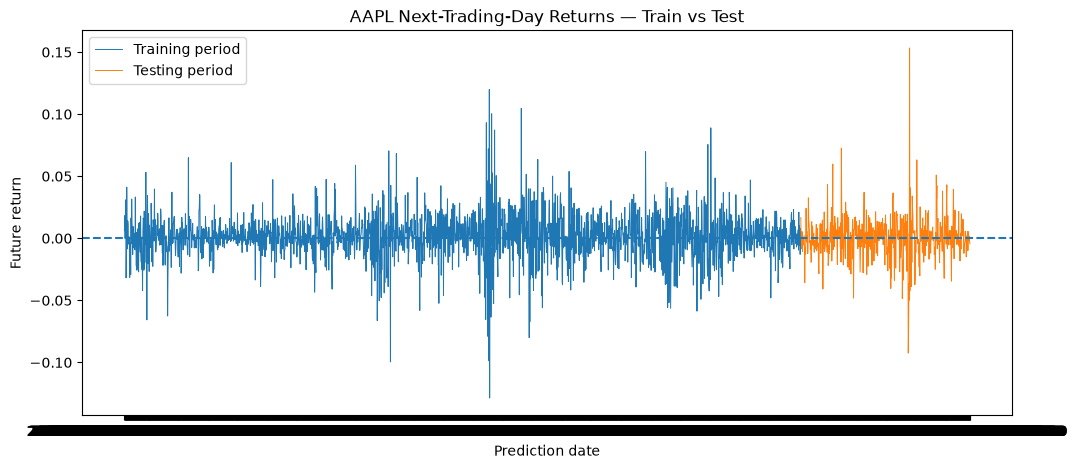

In [31]:
#Visualizing the future returns in the training and testing datasets
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["future_return_1d"],
    linewidth=0.7,
    label="Training period"
)

plt.plot(
    test.index,
    test["future_return_1d"],
    linewidth=0.7,
    label="Testing period"
)

plt.axhline(0, linestyle="--")

plt.title("AAPL Next-Trading-Day Returns — Train vs Test")
plt.xlabel("Prediction date")
plt.ylabel("Future return")

plt.legend()
plt.show()